# MÓDULO 35 - Cross Validation
## Previsão de Intenção de Compra de Clientes em Loja Web

### Contexto

A previsão da intenção de compra em sites de e-commerce é um recurso estratégico para aprimorar a experiência do cliente e direcionar de forma eficaz as ações de marketing da empresa. A análise de dados históricos de clientes, incluindo informações demográficas, renda, estado civil e comportamento de compra, pode revelar padrões importantes que indicam maior probabilidade de realizar compras online.

### 🎯 Objetivo Geral

Desenvolver um modelo preditivo para analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa.

### Objetivos Complementares

* **Pré-processamento pt-1:** Tratar variáveis não úteis, inconsistentes e preparar os dados para modelagem.  
* **Modelagem:** Implementar modelos de classificação supervisionada para prever a intenção de compra dos clientes.  
* **Avaliação:** Medir métricas de performance (acurácia, precisão, recall, F1-score) para verificar a robustez do modelo.  

### 🗄️ Base de Dados

A base de dados contém informações demográficas e de comportamento de consumo dos clientes, conforme a **Tabela 1**.

| Feature             | Descrição                                                      |
| ------------------- | -------------------------------------------------------------- |
| Year_Birth          | Ano de nascimento do cliente                                   |
| Education           | Nível de escolaridade do cliente                               |
| Marital_Status      | Estado civil do cliente                                        |
| Income              | Renda anual da família do cliente                              |
| Kidhome             | Número de crianças na casa do cliente                          |
| Recency             | Número de dias desde a última compra do cliente                |
| Complain            | 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário   |
| MntWines            | Valor gasto em vinhos nos últimos 2 anos                       |
| MntFruits           | Valor gasto em frutas nos últimos 2 anos                       |
| MntMeatProducts     | Valor gasto em carnes nos últimos 2 anos                       |
| MntFishProducts     | Valor gasto em peixes nos últimos 2 anos                       |
| MntSweetProducts    | Valor gasto em doces nos últimos 2 anos                        |
| MntGoldProds        | Valor gasto em produtos de ouro nos últimos 2 anos             |
| NumStorePurchases   | Número de compras feitas diretamente nas lojas                 |
| NumWebVisitsMonth   | Número de visitas ao site da empresa no último mês             |
| **WebPurchases**    | compra no website. 0 não, 1 sim.                 |

**Tabela 1**: Variáveis do dataframe


# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

## 1. Aquisição e Preparação de Dados

### 1.1 Data Load (Carregamento)
- Importar bibliotecas.  
- Carregar dados (CSV, Excel, SQL, API).  
- Verificar dimensões e primeiras linhas (`df.shape`, `df.head()`).  

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
dfo = pd.read_csv('/home/akel/PycharmProjects/EBAC/dados/marketing_campaign.csv', delimiter=';')


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)



dfo.head(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
5,1967,Master,Together,62513.0,0,16,520,42,98,0,42,14,10,6,0,1
6,1971,Graduation,Divorced,55635.0,0,34,235,65,164,50,49,27,7,6,0,1
7,1985,PhD,Married,33454.0,1,32,76,10,56,3,1,23,4,8,0,1
8,1974,PhD,Together,30351.0,1,19,14,0,24,3,3,2,2,9,0,0
9,1950,PhD,Together,5648.0,1,68,28,0,6,1,1,13,0,20,0,0


### 1.2 Pré-Processamento Inicial
- Exploração bruta (`df.info()`, `df.describe()`).  
- Tratamento de **valores faltantes** (remover ou imputar).  
- Remoção de **duplicados**.  


In [2]:
print("=" * 50)
print("ANÁLISE EXPLORATÓRIA DO DATAFRAME")
print("=" * 50)
# Informações sobre o shape dos dados
print(f"\n📊 DIMENSÕES: {dfo.shape[0]} linhas × {dfo.shape[1]} colunas")
df = dfo.copy()

# Informações sobre tipos de dados
print(f"\n🔧 TIPOS DE DADOS:")
print(df.dtypes.to_frame('Tipo').to_markdown())

# Contagem de duplicatas
print("=" * 50)
print("🔍 VERIFICAÇÃO DE DUPLICATAS & Nulos")
print(f"Total registros duplicados: {df.duplicated().sum()}")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")

print("=" * 50)
# Remoção duplicadas
df = df.drop_duplicates()
# remoção de nulos
if df.isnull().sum().sum()/(dfo.shape[0])*100 > 5:
    print('‼️ Avaliar critérios de exclusão')
else:
    df = df.dropna()
print("🧹 REMOÇÃO DE DUPLICATAS & Nulos")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")
print(f"Total registros duplicados: {df.duplicated().sum()}")
print(f"📊 Novas DIMENSÕES: {df.shape[0]} linhas × {df.shape[1]} colunas")


ANÁLISE EXPLORATÓRIA DO DATAFRAME

📊 DIMENSÕES: 2240 linhas × 16 colunas

🔧 TIPOS DE DADOS:
|                   | Tipo    |
|:------------------|:--------|
| Year_Birth        | int64   |
| Education         | object  |
| Marital_Status    | object  |
| Income            | float64 |
| Kidhome           | int64   |
| Recency           | int64   |
| MntWines          | int64   |
| MntFruits         | int64   |
| MntMeatProducts   | int64   |
| MntFishProducts   | int64   |
| MntSweetProducts  | int64   |
| MntGoldProds      | int64   |
| NumStorePurchases | int64   |
| NumWebVisitsMonth | int64   |
| Complain          | int64   |
| WebPurchases      | int64   |
🔍 VERIFICAÇÃO DE DUPLICATAS & Nulos
Total registros duplicados: 201
Total de valores nulos: 24
🧹 REMOÇÃO DE DUPLICATAS & Nulos
Total de valores nulos: 0
Total registros duplicados: 0
📊 Novas DIMENSÕES: 2015 linhas × 16 colunas


### 1.3 Limpeza e Consistência
- Padronização de categorias.  
- Tratamento de valores inválidos.  

In [3]:
# Padronização de categorias
df["Marital_Status"] = df["Marital_Status"].replace({
     "Single": "Single",
     "Alone": "Single",
     "YOLO": "Other",
     "Absurd": "Other",
    "Together": "Married",
     "Married": "Married",
     "Divorced": "Divorced",
     "Widow": "Widow"})

# Consistencia de valores 
# 1915 < anos de nascimento < 2015
df = df[(df["Year_Birth"] >= 1915) & (df["Year_Birth"] <= 2015)]
# renda deve ser positiva >0
df = df[df["Income"] > 0]        

print("=" * 50)
print("RESUMO")
print("=" * 50)
# Padronização de categorias
print("CATEGORIAS:")
for col in ["Education", "Marital_Status"]:
    if col in df.columns:
        print(f"{str.upper(col)}: {df[col].unique()}")
print(f"📊 Novas DIMENSÕES: {df.shape[0]} linhas × {df.shape[1]} colunas")

RESUMO
CATEGORIAS:
EDUCATION: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
MARITAL_STATUS: ['Single' 'Married' 'Divorced' 'Widow' 'Other']
📊 Novas DIMENSÕES: 2012 linhas × 16 colunas


---

## 2. Análise Exploratória e Engenharia de Variáveis

### 2.1 EDA (Exploratory Data Analysis)
- Distribuição de variáveis.  
- Relação entre variáveis.  
- Correlações e heatmap.  
- Identificação de outliers.  



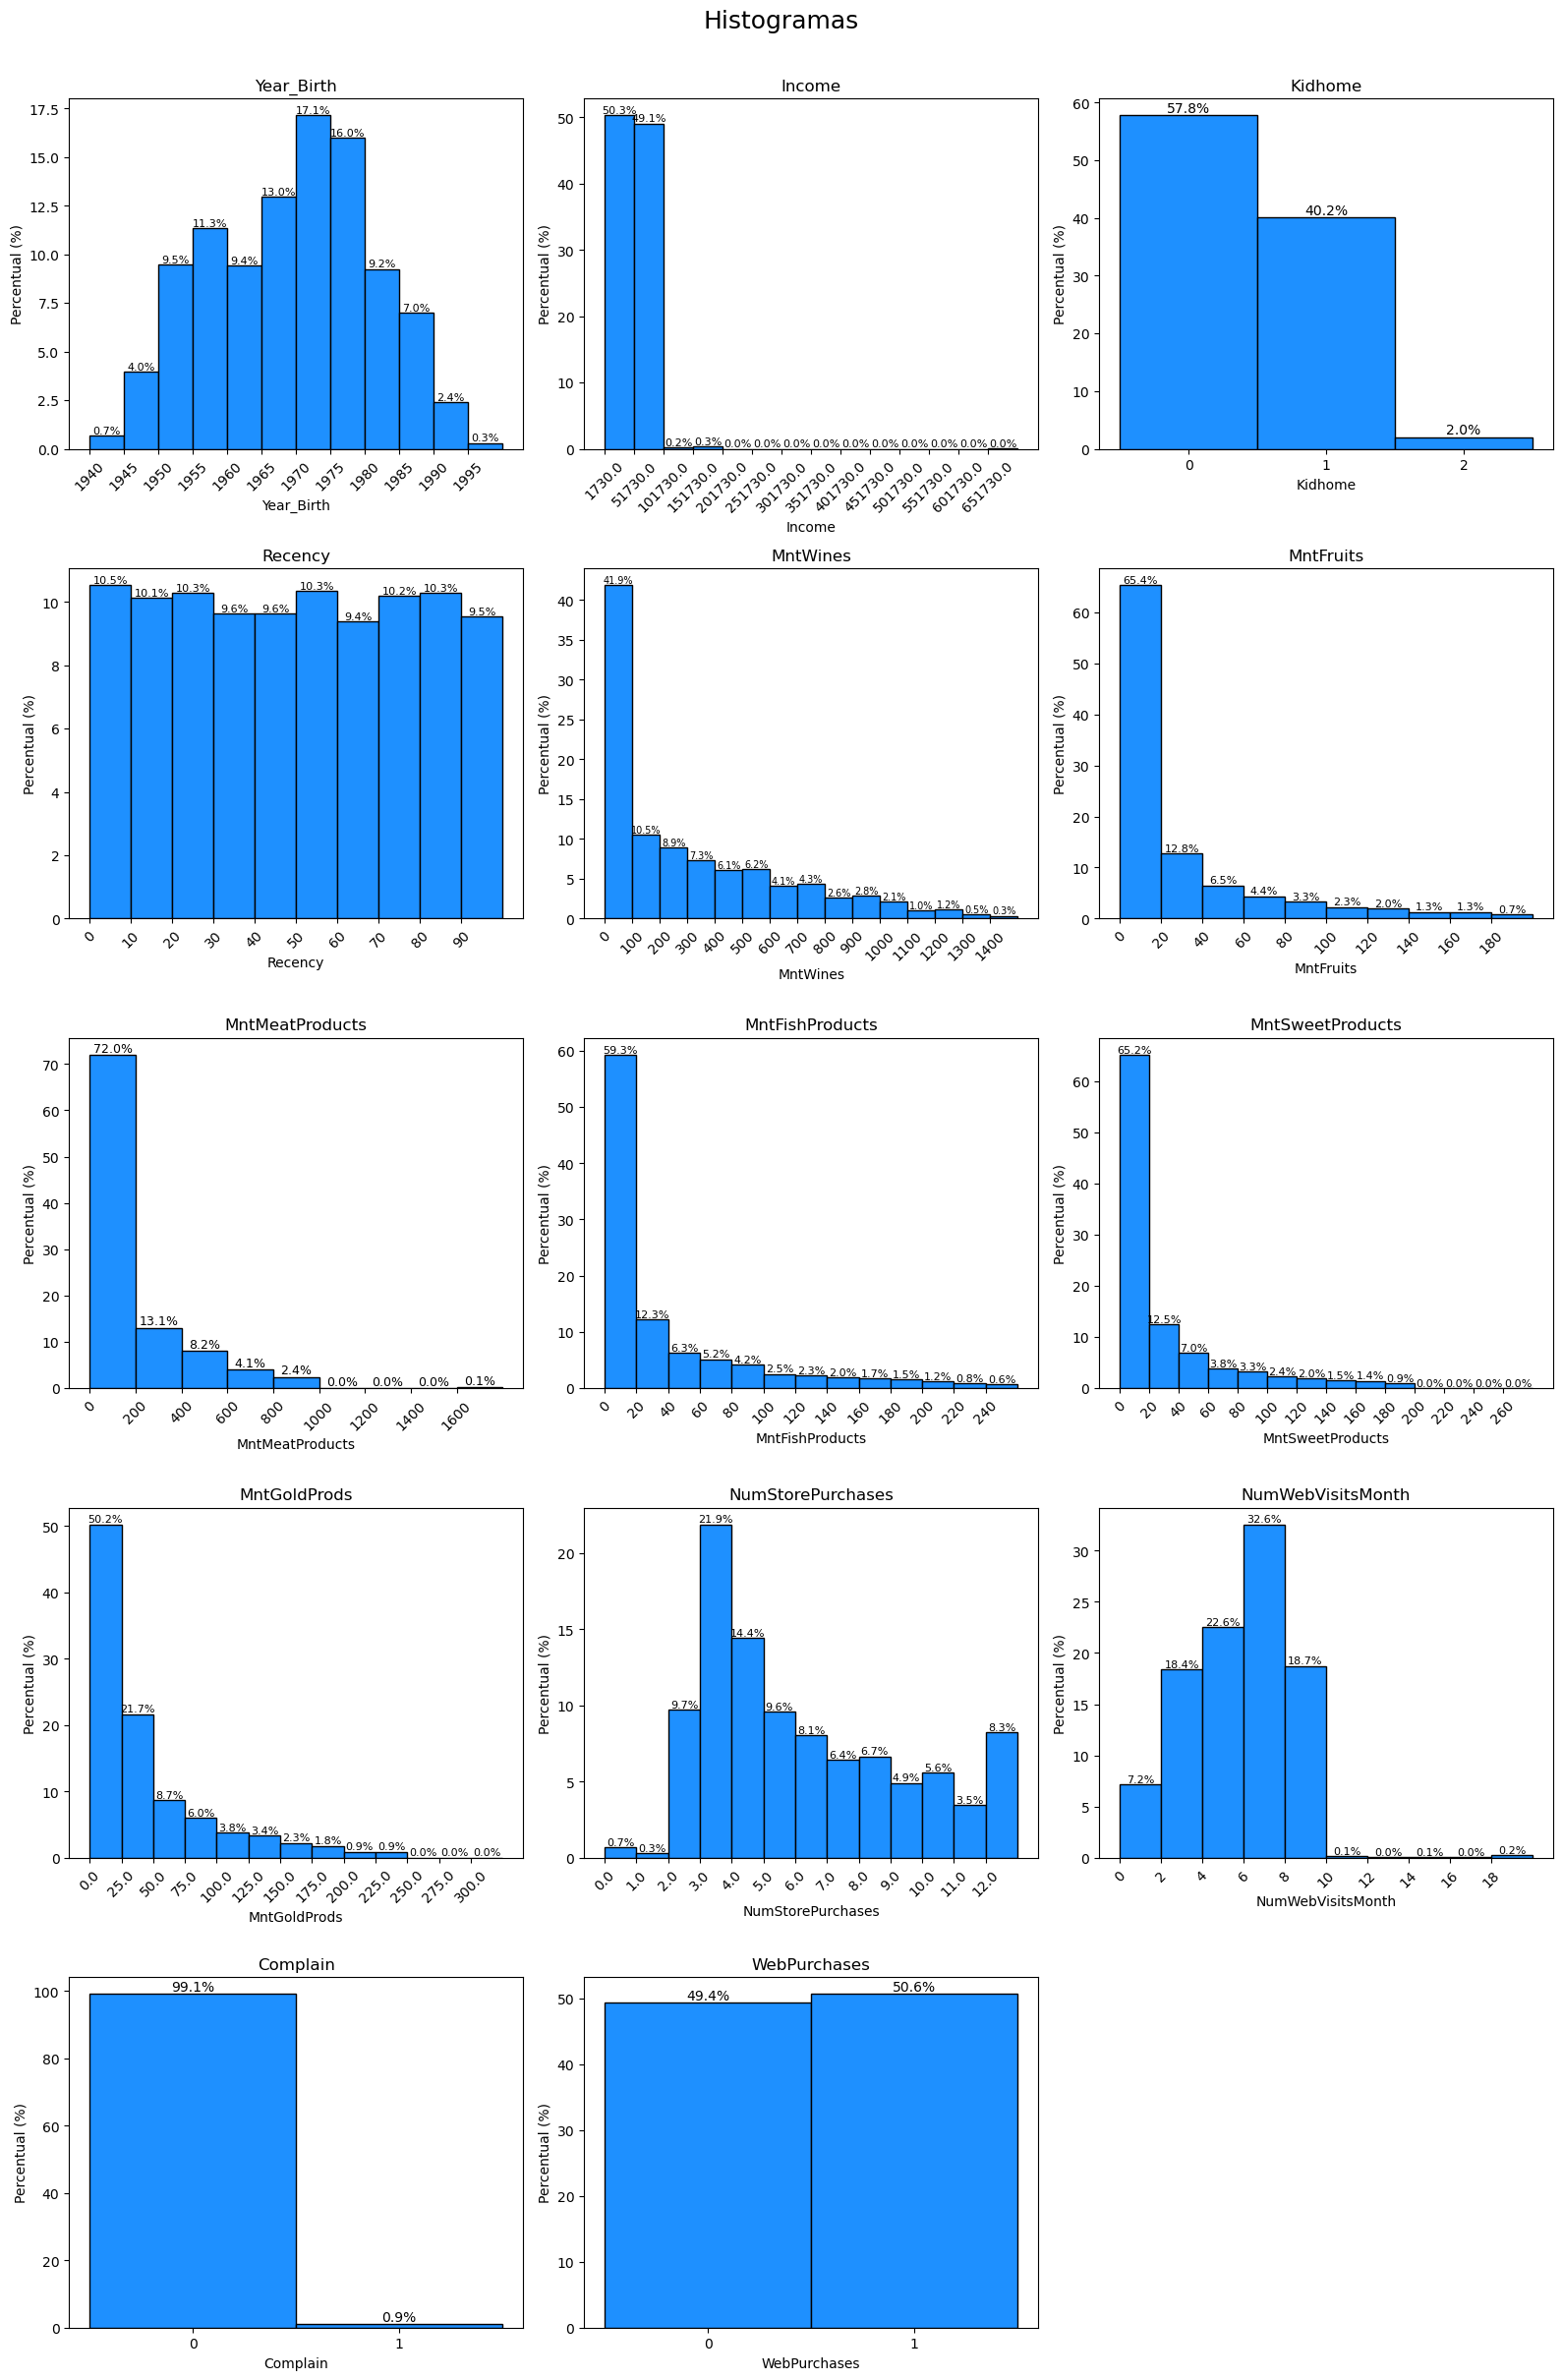

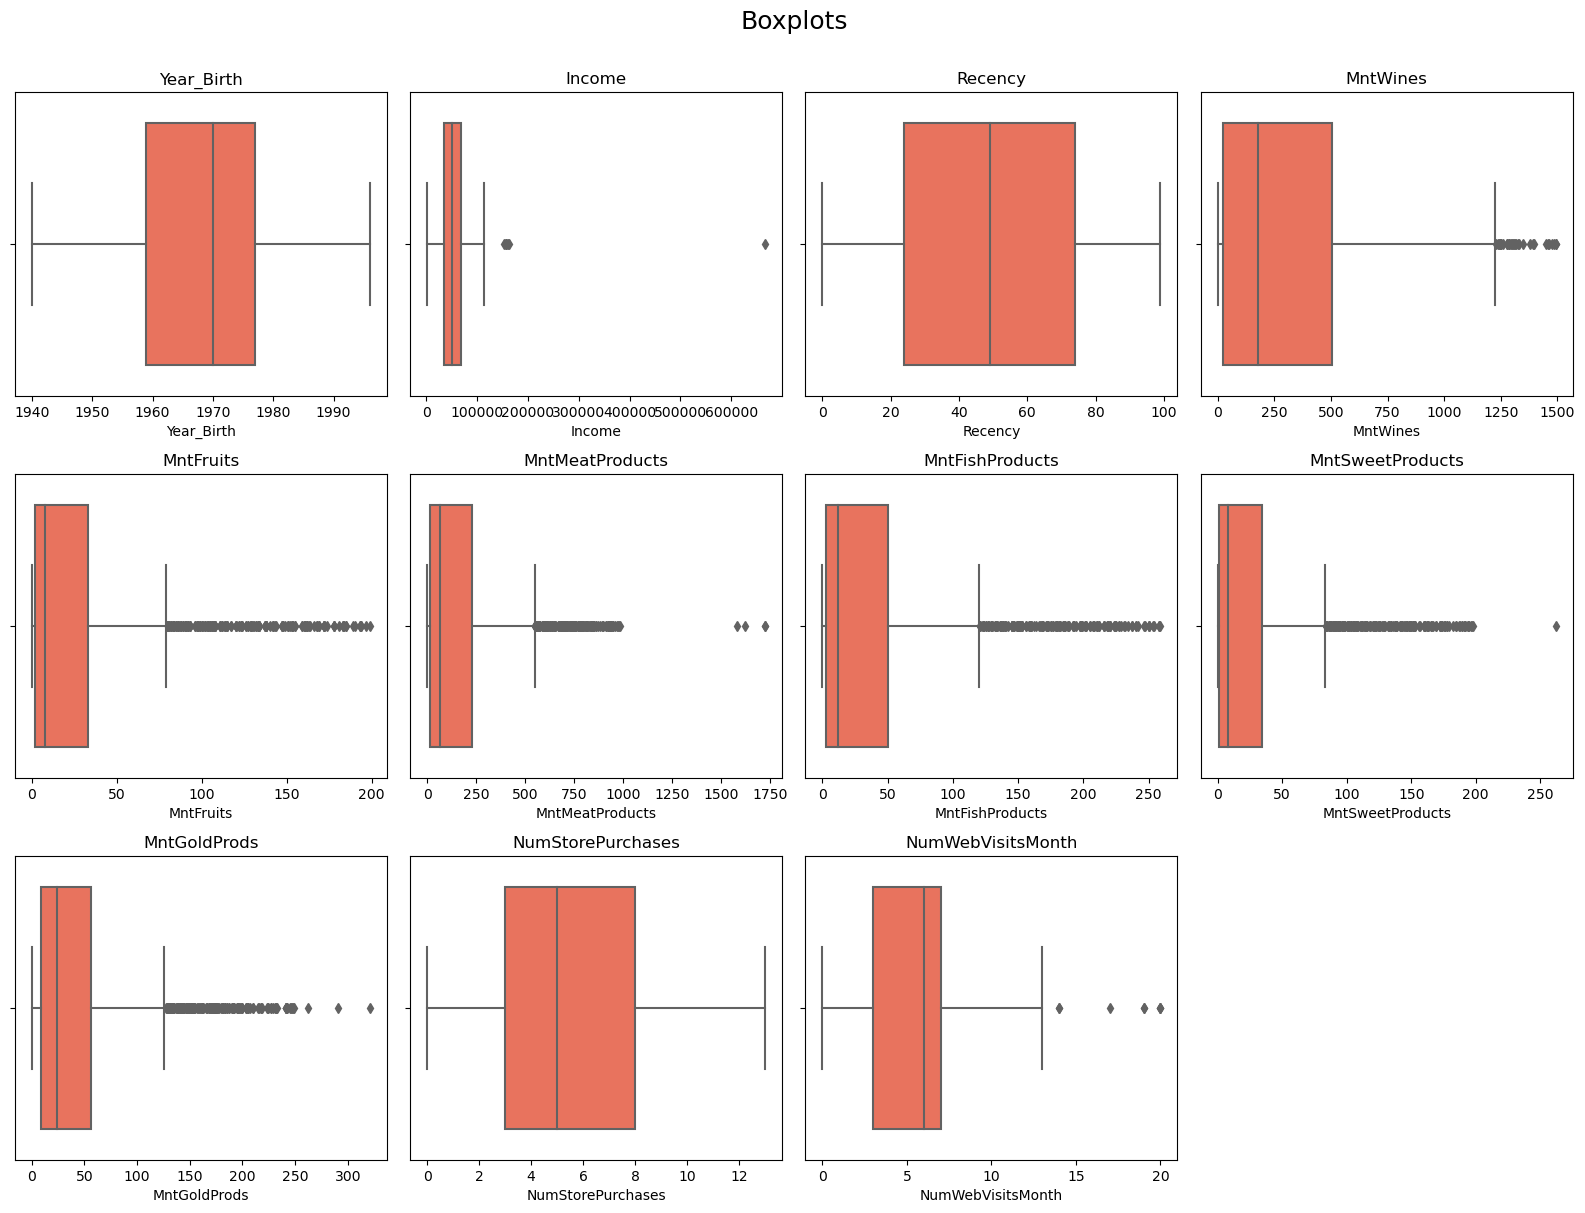

In [9]:
def mult_plt(df,kind='hist', ncols=3, max_bins=15, figsize=(16, 24),min_boxplot=6,suptitle=None):

    
    """
    Gera automaticamente visualizações (histogramas ou boxplots)
    para todas as colunas numéricas de um DataFrame.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas numéricas para visualização.
    kind : str, padrão="hist"
        Tipo de visualização: "hist" para histograma ou "box" para boxplot.
    ncols : int, padrão=3
        Número de colunas no grid de subplots.
    max_bins : int, padrão=15
        Máximo de bins para histogramas.
    figsize : Tuple[int, int], padrão=(16, 24)
        Tamanho da figura.
    suptitle : str, opcional
        Título geral da figura.
    min_unique_values_for_boxplot : int, padrão=6
        Número mínimo de valores únicos para incluir a variável em boxplot.

    Retorno
    -------
    None
        Exibe os gráficos diretamente.
    """

    def nice_bin_width(data_range: float, max_bins: int) -> float:
        """Calcula largura de bin 'redonda' para histogramas."""
        raw_dx = data_range / max_bins
        nice_steps = [1, 2, 2.5, 5, 10]
        scale = 10 ** math.floor(math.log10(raw_dx))
        for step in nice_steps:
            candidate = step * scale
            n_bins = math.ceil(data_range / candidate)
            if n_bins <= max_bins:
                return candidate
        return data_range / max_bins

    cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # FILTRAR COLUNAS para boxplot
    if kind == "box":
        cols = [col for col in cols if df[col].nunique() >= min_boxplot]

    nrows = math.ceil(len(cols) / ncols)

    fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
    ax = np.array(ax).reshape(nrows, ncols)

    if not suptitle:
        suptitle = "Histogramas" if kind == "hist" else "Boxplots"
    fig.suptitle(suptitle, fontsize=18, y=1.007)

    for idx, col in enumerate(cols):
        row, col_idx = divmod(idx, ncols)
        temp = df[col].dropna()

        if kind == "hist":
            unique_vals = np.sort(temp.unique())
            if np.issubdtype(temp.dtype, np.integer) and len(unique_vals) <= 8:
                dx = 1
                align = 'center'
                bins = np.arange(min(unique_vals), max(unique_vals) + dx + 1, dx)
            else:
                data_range = temp.max() - temp.min()
                dx = nice_bin_width(data_range, max_bins)
                align = 'edge'
                bins = np.arange(temp.min(), temp.max() + dx, dx)

            counts, edges = np.histogram(temp, bins)
            perc = counts / len(temp) * 100

            ax[row, col_idx].bar(
                edges[:-1], perc, width=np.diff(bins), align=align,
                color='dodgerblue', edgecolor='black'
            )
            ax[row, col_idx].set_title(col)
            ax[row, col_idx].set_xlabel(col)
            ax[row, col_idx].set_ylabel('Percentual (%)')
            ax[row, col_idx].set_xticks(bins[:-1])
            if len(bins) >= 10:
                ax[row, col_idx].set_xticklabels(bins[:-1], rotation=45)

            for i in range(len(counts)):
                fs = max(6, 10 - len(counts) // 5)
                if align == 'center':
                    bar_center = bins[i]
                else:
                    bar_center = bins[i] + (bins[i + 1] - bins[i]) / 2
                ax[row, col_idx].text(
                    bar_center, perc[i], f'{perc[i]:.1f}%',
                    ha='center', va='bottom', fontsize=fs
                )

        elif kind == "box":
            sns.boxplot(x=temp, color="tomato", ax=ax[row, col_idx])
            ax[row, col_idx].set_title(col)
            ax[row, col_idx].set_xlabel(col)
            ax[row, col_idx].set_ylabel("")

    # Remove subplots extras
    for j in range(len(cols), nrows * ncols):
        row, col_idx = divmod(j, ncols)
        ax[row, col_idx].set_visible(False)

    plt.tight_layout()
    plt.show()
    
mult_plt(df)
mult_plt(df,kind='box',ncols=4,figsize=(16, 12))  
